<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Fundamentals_and_Applications/final_project_Sofiia_Bobrivets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Фінальний проєкт — Binary Classification (V2)
## Machine Learning: Fundamentals and Applications

**Студентка:** Sofiia Bobrivets

### Мета V2
Покращити baseline `Balanced Accuracy = 0.80716`, отриманий у першій версії.

Основна зміна: замість One-Hot Encoding для категоріальних ознак використовується **CatBoost**, який працює з категоріями напряму. Це особливо доречно для цього набору, де є high-cardinality категоріальні ознаки.

Для чесної оцінки:
- використовується `StratifiedKFold`;
- категоріальні значення не target-encode-яться вручну;
- threshold підбирається лише на out-of-fold прогнозах;
- Kaggle test не використовується для вибору параметрів.


## 1. Бібліотеки

In [1]:
!pip -q install catboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from catboost import CatBoostClassifier

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "y"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


## 2. Завантаження даних

In [2]:
BASE_URL = "https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/competition/"

train = pd.read_csv(BASE_URL + "final_proj_data.csv")
test = pd.read_csv(BASE_URL + "final_proj_test.csv")
sample_submission = pd.read_csv(BASE_URL + "final_proj_sample_submission.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Sample submission:", sample_submission.shape)
display(train.head())


Train: (10000, 231)
Test: (2500, 230)
Sample submission: (2500, 2)


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,y
0,NaN,NaN,NaN,NaN,NaN,812.0,14.0,NaN,NaN,NaN,...,catzS2D,jySVZNlOJy,NaN,xG3x,Aoh3,ZI9m,ib5G6X1eUxUn6,mj86,NaN,0
1,NaN,NaN,NaN,NaN,NaN,2688.0,7.0,NaN,NaN,NaN,...,i06ocsg,LM8l689qOp,NaN,kG3k,WqMG,RAYp,55YFVY9,mj86,NaN,0
2,NaN,NaN,NaN,NaN,NaN,1015.0,14.0,NaN,NaN,NaN,...,P6pu4Vl,LM8l689qOp,NaN,kG3k,Aoh3,ZI9m,R4y5gQQWY8OodqDV,am7c,NaN,0
3,NaN,NaN,NaN,NaN,NaN,168.0,0.0,NaN,NaN,NaN,...,BNrD3Yd,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,14.0,0.0,NaN,NaN,NaN,...,3B1QowC,LM8l689qOp,NaN,NaN,WqMG,RAYp,F2FyR07IdsN7I,NaN,NaN,0


## 3. Підготовка ознак

In [3]:
X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].astype(int).copy()
X_test = test.copy()

# Якщо є технічний index, не використовуємо його як ознаку.
id_col = "index" if "index" in X.columns and "index" in X_test.columns else None
if id_col is not None:
    X = X.drop(columns=[id_col])
    X_test = X_test.drop(columns=[id_col])

cat_features = X.select_dtypes(exclude=np.number).columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

# CatBoost очікує коректні categorical values; пропуски замінюємо окремим маркером.
for col in cat_features:
    X[col] = X[col].fillna("__MISSING__").astype(str)
    X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

# Числові пропуски заповнюємо медіанами train.
for col in num_features:
    median = X[col].median()
    X[col] = X[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

print("Numeric:", len(num_features))
print("Categorical:", len(cat_features))
print("Class distribution:")
display(y.value_counts(normalize=True).sort_index().to_frame("share"))

cardinality = X[cat_features].nunique().sort_values(ascending=False)
display(cardinality.head(15).to_frame("n_unique"))


Numeric: 192
Categorical: 38
Class distribution:


,share
y,
0,0.8695
1,0.1305


,n_unique
Var217,5530
Var200,4479
Var214,4479
Var202,3802
Var220,2100
Var222,2100
Var198,2100
Var199,1850
Var216,977
Var192,298


## 4. CatBoost: 5-fold OOF експерименти

Перевіряємо кілька компактних конфігурацій. Мета — знайти кращий варіант за **OOF Balanced Accuracy**, не дивлячись на Kaggle test.


In [4]:
configs = {
    "CB_balanced_d6": dict(
        iterations=700,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5,
        auto_class_weights="Balanced"
    ),
    "CB_sqrtbalanced_d7": dict(
        iterations=800,
        depth=7,
        learning_rate=0.04,
        l2_leaf_reg=7,
        auto_class_weights="SqrtBalanced"
    ),
    "CB_balanced_d7": dict(
        iterations=800,
        depth=7,
        learning_rate=0.04,
        l2_leaf_reg=7,
        auto_class_weights="Balanced"
    )
}

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

experiment_rows = []
oof_by_model = {}

for name, params in configs.items():
    print("\n===", name, "===")
    oof = np.zeros(len(X), dtype=float)
    fold_scores_05 = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="BalancedAccuracy",
            random_seed=RANDOM_STATE + fold,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
            **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features,
            eval_set=(X_va, y_va),
            early_stopping_rounds=100,
            verbose=False
        )

        proba = model.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba

        score_05 = balanced_accuracy_score(y_va, (proba >= 0.5).astype(int))
        fold_scores_05.append(score_05)
        print(f"Fold {fold}: {score_05:.5f}")

    oof_by_model[name] = oof

    # Threshold tuning on full OOF predictions.
    thresholds = np.linspace(0.20, 0.80, 121)
    scores = np.array([
        balanced_accuracy_score(y, (oof >= t).astype(int))
        for t in thresholds
    ])
    best_i = int(np.argmax(scores))

    experiment_rows.append({
        "model": name,
        "cv_mean_at_0.5": np.mean(fold_scores_05),
        "cv_std_at_0.5": np.std(fold_scores_05),
        "best_threshold": thresholds[best_i],
        "oof_balanced_accuracy": scores[best_i]
    })

results_v2 = (
    pd.DataFrame(experiment_rows)
    .sort_values("oof_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

display(results_v2)



=== CB_balanced_d6 ===
Fold 1: 0.90265
Fold 2: 0.87505
Fold 3: 0.89575
Fold 4: 0.89785
Fold 5: 0.89144

=== CB_sqrtbalanced_d7 ===
Fold 1: 0.86646
Fold 2: 0.85123
Fold 3: 0.85880
Fold 4: 0.87853
Fold 5: 0.85496

=== CB_balanced_d7 ===
Fold 1: 0.89105
Fold 2: 0.87687
Fold 3: 0.89460
Fold 4: 0.89479
Fold 5: 0.89287


,model,cv_mean_at_0.5,cv_std_at_0.5,best_threshold,oof_balanced_accuracy
0,CB_balanced_d6,0.892550,0.009462,0.50,0.892550
1,CB_balanced_d7,0.890038,0.006720,0.50,0.890038
2,CB_sqrtbalanced_d7,0.861996,0.009683,0.24,0.887921


## 5. Вибір найкращої конфігурації та детальна OOF-оцінка

Best model: CB_balanced_d6
Best threshold: 0.5
OOF Balanced Accuracy: 0.89255

Baseline V1: 0.80716
Improvement: 0.08539

Confusion matrix:
[[7586 1109]
 [ 114 1191]]

Classification report:
              precision    recall  f1-score   support

           0     0.9852    0.8725    0.9254      8695
           1     0.5178    0.9126    0.6607      1305

    accuracy                         0.8777     10000
   macro avg     0.7515    0.8925    0.7931     10000
weighted avg     0.9242    0.8777    0.8909     10000



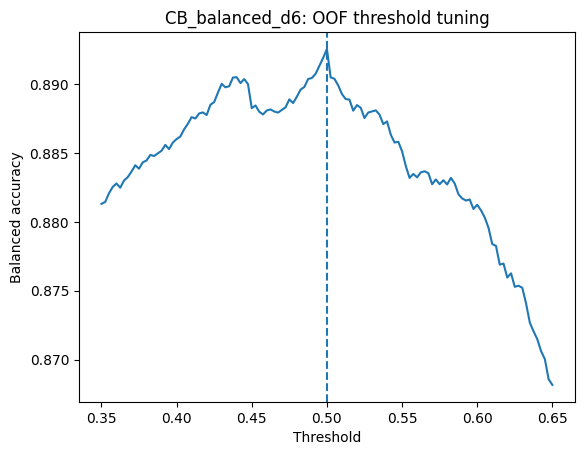

In [5]:
best_name = results_v2.loc[0, "model"]
best_threshold = float(results_v2.loc[0, "best_threshold"])
best_oof = oof_by_model[best_name]

oof_pred = (best_oof >= best_threshold).astype(int)
oof_score = balanced_accuracy_score(y, oof_pred)

print("Best model:", best_name)
print("Best threshold:", round(best_threshold, 3))
print("OOF Balanced Accuracy:", round(oof_score, 5))
print("\nBaseline V1: 0.80716")
print("Improvement:", round(oof_score - 0.80716, 5))

print("\nConfusion matrix:")
print(confusion_matrix(y, oof_pred))

print("\nClassification report:")
print(classification_report(y, oof_pred, digits=4))

threshold_grid = np.linspace(max(0.1, best_threshold - 0.15),
                             min(0.9, best_threshold + 0.15), 121)
threshold_grid_scores = [
    balanced_accuracy_score(y, (best_oof >= t).astype(int))
    for t in threshold_grid
]

plt.plot(threshold_grid, threshold_grid_scores)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Balanced accuracy")
plt.title(f"{best_name}: OOF threshold tuning")
plt.show()


## 6. Фінальна модель

Фінальна модель використовує конфігурацію, що дала найкращий OOF результат. Кількість ітерацій береться з відповідної конфігурації, після чого модель навчається на всіх 10 000 train-об'єктах.


In [6]:
best_params = configs[best_name]

final_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="BalancedAccuracy",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
    **best_params
)

final_model.fit(
    X,
    y,
    cat_features=cat_features,
    verbose=False
)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print("Розподіл прогнозів:")
print(pd.Series(test_pred).value_counts().sort_index())


Розподіл прогнозів:
0    2039
1     461
Name: count, dtype: int64


## 7. Feature importance

,feature,importance
0,Var126,32.001990
1,Var212,6.837801
2,Var73,4.826704
3,Var74,4.175999
4,Var199,2.790048
5,Var144,2.640626
6,Var216,2.636459
7,Var57,2.540734
8,Var81,2.407705
9,Var149,2.167988


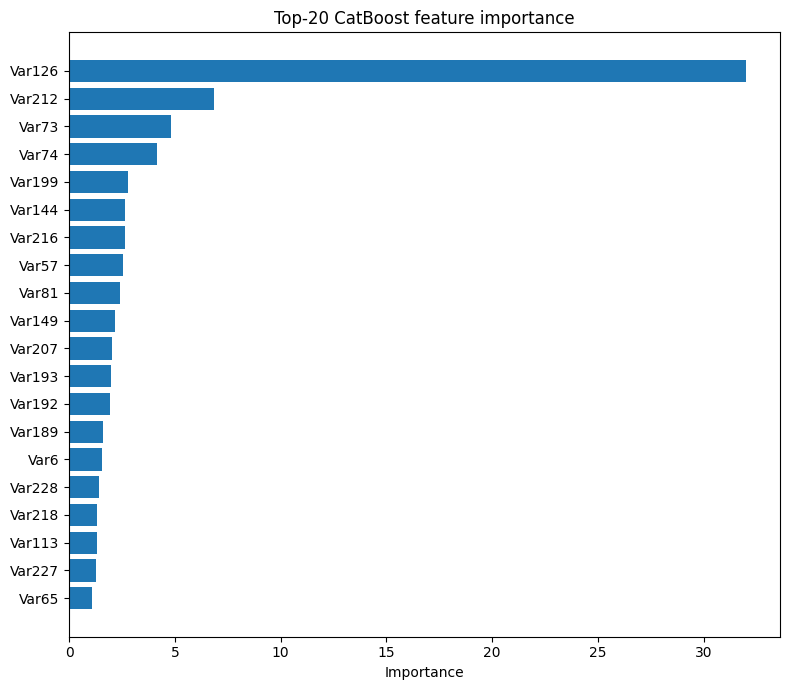

In [7]:
importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": final_model.get_feature_importance()
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(25))

top = importance.head(20).sort_values("importance")
plt.figure(figsize=(8, 7))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Importance")
plt.title("Top-20 CatBoost feature importance")
plt.tight_layout()
plt.show()


## 8. Створення submission

In [8]:
submission = sample_submission.copy()

if len(submission) != len(test_pred):
    raise ValueError("Кількість прогнозів не відповідає sample submission.")

submission[TARGET] = test_pred.astype(int)
submission.to_csv("submission_v2.csv", index=False)

print("Submission:", submission.shape)
print("Columns:", submission.columns.tolist())
display(submission.head(10))
display(submission[TARGET].value_counts().sort_index().to_frame("count"))


Submission: (2500, 2)
Columns: ['index', 'y']


,index,y
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,0
8,8,1
9,9,0


,count
y,
0,2039
1,461


## 9. Висновок

У фінальному проєкті було розроблено модель бінарної класифікації для прогнозування відтоку клієнтів на основі набору даних із числовими та категоріальними ознаками. Через значний дисбаланс цільової змінної основною метрикою оцінювання було обрано `Balanced Accuracy`.

На першому етапі було протестовано Logistic Regression, Random Forest та Extra Trees. Найкращий результат серед цих моделей показав Random Forest. Після підбору порогу класифікації було отримано OOF Balanced Accuracy **0.80716**.

Для покращення результату було використано CatBoost, який дозволяє працювати з категоріальними ознаками без попереднього One-Hot Encoding. Декілька конфігурацій моделі було порівняно за допомогою 5-fold `StratifiedKFold`. Найкращий результат показала конфігурація `CB_balanced_d6` з автоматичним балансуванням класів.

За результатами крос-валідації фінальна модель отримала OOF Balanced Accuracy **0.89255**, що на **0.08539** вище за результат першої версії. Оптимальним порогом класифікації залишився стандартний поріг **0.5**.

Після вибору найкращої конфігурації модель було навчено на всьому навчальному наборі даних та сформовано прогнози для 2500 об'єктів валідаційного набору. Результати було збережено у файлі `submission_v2.csv` та подано на Kaggle.

За результатами оцінювання на Kaggle модель отримала **Public Score 0.8879** та **Private Score 0.9008** за метрикою Balanced Accuracy. Отримані значення близькі до результату крос-валідації, що свідчить про стабільну якість моделі на даних, які не використовувалися під час її навчання.

Таким чином, перехід від базових моделей до CatBoost, нативна обробка категоріальних ознак та врахування дисбалансу класів дозволили суттєво покращити якість класифікації та отримати Balanced Accuracy близько **0.90** на даних Kaggle.
